<a href="https://colab.research.google.com/github/ParushiSrivastava/disease-pridiction-w-drone/blob/main/plant_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub tensorflow pillow matplotlib opencv-python-headless scikit-learn seaborn
print(' Libraries installed')

 Libraries installed


In [2]:
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Config — 224 is correct for EfficientNetB0
IMG_SIZE   = 224
BATCH_SIZE = 32

print(' All imports successful')
print(f'   TensorFlow : {tf.__version__}')
print(f'   GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

 All imports successful
   TensorFlow : 2.19.0
   GPU        : True


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import os

extract_path = "/content/drive/MyDrive/mendeley_dataset_converted"

print(os.listdir(extract_path))

['leaf']


In [22]:
mendeley_path = os.path.join(extract_path, "leaf")

print("Using:", mendeley_path)
print(os.listdir(mendeley_path))

Using: /content/drive/MyDrive/mendeley_dataset_converted/leaf
['neem leaf', 'Jujube', 'Bougainvillea leaf']


In [23]:
for folder, label in {
    "neem leaf": "Neem___healthy",
    "Bougainvillea leaf": "Bougainvillea___healthy"
}.items():

    folder_path = os.path.join(mendeley_path, folder)

    for fname in os.listdir(folder_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(folder_path, fname))
            all_labels.append(label)

In [24]:
all_images, all_labels = [], []

# PlantVillage
for label in sorted(os.listdir(base_dir)):
    label_dir = os.path.join(base_dir, label)
    if not os.path.isdir(label_dir):
        continue

    for fname in os.listdir(label_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(label_dir, fname))
            all_labels.append(label)

# Mendeley (YOUR FIXED PART)
extra_classes = {
    "neem leaf": "Neem___healthy",
    "Bougainvillea leaf": "Bougainvillea___healthy"
}

for folder, label in extra_classes.items():
    folder_path = os.path.join(mendeley_path, folder)

    for fname in os.listdir(folder_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(folder_path, fname))
            all_labels.append(label)

print("Total images:", len(all_images))
print("Total classes:", len(set(all_labels)))
print("Neem included:", "Neem___healthy" in set(all_labels))
print("Bougainvillea included:", "Bougainvillea___healthy" in set(all_labels))

Total images: 54511
Total classes: 40
Neem included: True
Bougainvillea included: True


In [25]:
# 70% train, 30% temp
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    all_images,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

# 15% val, 15% test
val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs,
    temp_lbls,
    test_size=0.50,
    stratify=temp_lbls,
    random_state=42
)

# Class maps
unique_labels = sorted(set(all_labels))
label_to_idx = {l: i for i, l in enumerate(unique_labels)}
idx_to_class = {v: k for k, v in label_to_idx.items()}
NUM_CLASSES = len(unique_labels)

with open("class_indices.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)

# Class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(label_to_idx.values())),
    y=[label_to_idx[l] for l in train_lbls]
)

class_weight_dict = dict(enumerate(class_weights_array))

print("Split complete")
print(f"  Train   : {len(train_imgs):,}")
print(f"  Val     : {len(val_imgs):,}")
print(f"  Test    : {len(test_imgs):,}")
print(f"  Classes : {NUM_CLASSES}")
print(f"  Class weight range: {class_weights_array.min():.2f} – {class_weights_array.max():.2f}")

print("\nNew classes check:")
print("Neem___healthy" in unique_labels)
print("Bougainvillea___healthy" in unique_labels)

Split complete
  Train   : 38,157
  Val     : 8,177
  Test    : 8,177
  Classes : 40
  Class weight range: 0.25 – 29.81

New classes check:
True
True


In [26]:
def augment_lighting(img):
    img = img.copy()

    img = np.clip(img * np.random.uniform(0.4, 1.6), 0, 255)

    img[:, :, 0] = np.clip(img[:, :, 0] * np.random.uniform(0.85, 1.15), 0, 255)
    img[:, :, 1] = np.clip(img[:, :, 1] * np.random.uniform(0.90, 1.10), 0, 255)
    img[:, :, 2] = np.clip(img[:, :, 2] * np.random.uniform(0.85, 1.15), 0, 255)

    if np.random.rand() > 0.5:
        h, w = img.shape[:2]
        x1, x2 = sorted(np.random.randint(0, w, 2))
        y1, y2 = sorted(np.random.randint(0, h, 2))
        img[y1:y2, x1:x2] = np.clip(img[y1:y2, x1:x2] * 0.4, 0, 255)

    if np.random.rand() > 0.5:
        k = np.random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)

    if np.random.rand() > 0.5:
        quality = int(np.random.randint(50, 95))
        ret, enc = cv2.imencode(
            '.jpg',
            img.astype(np.uint8),
            [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        )
        if ret:
            img = cv2.imdecode(enc, cv2.IMREAD_COLOR).astype(np.float32)

    return img.astype(np.float32)


def make_dataset(image_paths, labels, augment=False, batch_size=BATCH_SIZE):
    int_labels = [label_to_idx[l] for l in labels]

    def load_and_resize(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        return img, label

    def geometric_aug(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        return img, label

    def lighting_aug(img, label):
        img = tf.numpy_function(augment_lighting, [img], tf.float32)
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, label

    def apply_preprocess(img, label):
        img = tf.numpy_function(preprocess_input, [img], tf.float32)
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, label

    def make_one_hot(img, label):
        return img, tf.one_hot(label, NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, int_labels))

    if augment:
        ds = ds.shuffle(
            buffer_size=min(len(image_paths), 10000),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_resize, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(geometric_aug, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lighting_aug, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(apply_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(make_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(train_imgs, train_lbls, augment=True)
val_ds   = make_dataset(val_imgs, val_lbls, augment=False)
test_ds  = make_dataset(test_imgs, test_lbls, augment=False)

print("Data pipeline ready")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

Data pipeline ready
Train batches: 1193
Val batches  : 256
Test batches : 256


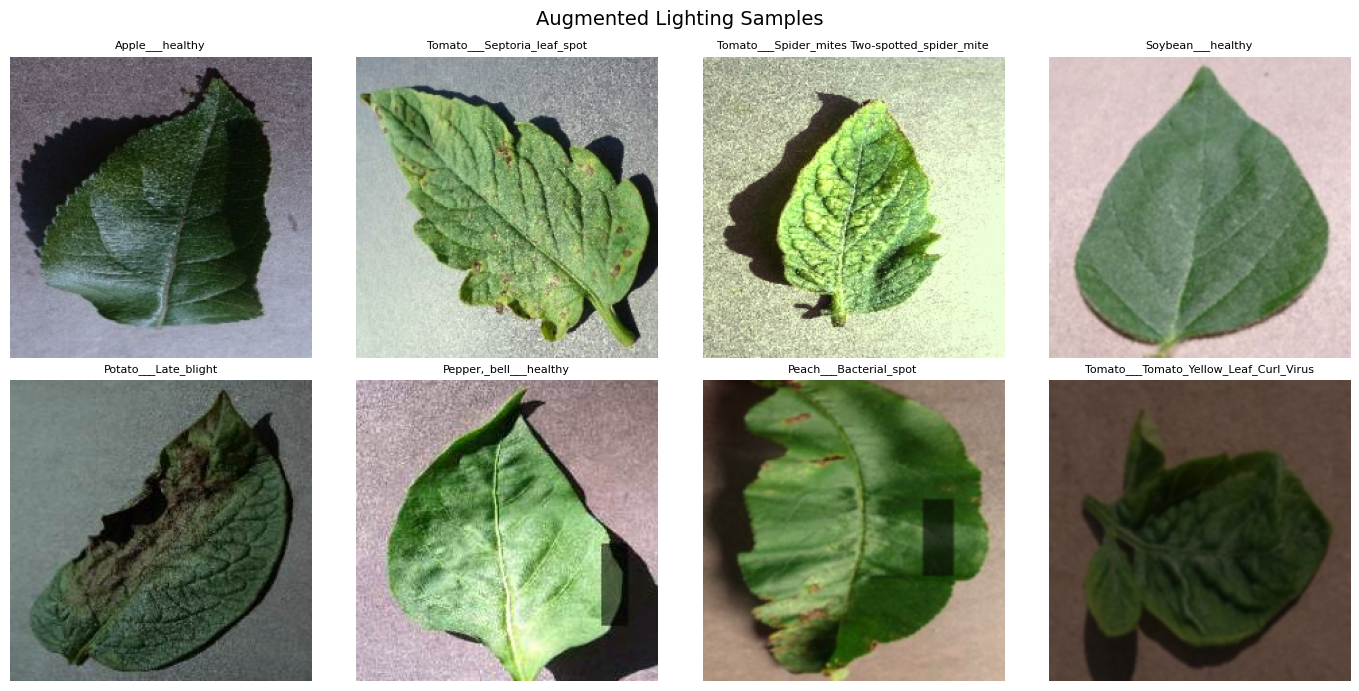

In [ ]:
def make_viz_dataset(image_paths, labels, batch_size=8):
    int_labels = [label_to_idx[l] for l in labels]

    def load_and_resize(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        return img, label

    def geometric_aug(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        return img, label

    def lighting_aug(img, label):
        img = tf.numpy_function(augment_lighting, [img], tf.float32)
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((image_paths, int_labels))
    ds = ds.shuffle(min(len(image_paths), 1000), seed=42)
    ds = ds.map(load_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(geometric_aug, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lighting_aug, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    return ds


viz_ds = make_viz_dataset(train_imgs, train_lbls, batch_size=8)

sample_imgs, sample_lbls = next(iter(viz_ds))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Augmented Lighting Samples", fontsize=14)

for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].numpy().astype(np.float32)

    # scale to 0-1 only for display
    img = np.clip(img / 255.0, 0, 1)

    ax.imshow(img)
    ax.set_title(idx_to_class[int(sample_lbls[i].numpy())], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

backbone = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
backbone.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = backbone(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32'
)(x)

model = Model(inputs, outputs, name='PlantDisease_EfficientNetB0')

print("Model built")
print("Total params:", model.count_params())

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built
Total params: 4731083


In [28]:
callbacks_p1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training head only...")

hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict
)
print(f'\nPhase 1 complete — best val accuracy: {max(hist1.history["val_accuracy"]):.2%}')

Phase 1: Training head only...
Epoch 1/12
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6636 - loss: 1.3886
Epoch 1: val_accuracy improved from None to 0.88688, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 555s 410ms/step - accuracy: 0.7566 - loss: 0.9731 - val_accuracy: 0.8869 - val_loss: 0.4962 - learning_rate: 0.0010
Epoch 2/12
1192/1193 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8246 - loss: 0.7718
Epoch 2: val_accuracy improved from 0.88688 to 0.91268, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 155s 130ms/step - accuracy: 0.8356 - loss: 0.7157 - val_accuracy: 0.9127 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 3/12
1192/1193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8593 - loss: 0.5935
Epoch 3: val_accuracy improved from 0.91268 to 0.94741, saving model to best_phase1.keras

Epoch 3: finished saving model 

In [29]:
model.load_weights('best_phase1.keras')

backbone.trainable = True
for layer in backbone.layers[:-15]:
    layer.trainable = False

callbacks_p2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine-tuning...")

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict
)

model.save("plant_disease_efficientnet.keras")
print("Saved: plant_disease_efficientnet.keras")

Phase 2: Fine-tuning...
Epoch 1/8
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8252 - loss: 0.7270
Epoch 1: val_accuracy improved from None to 0.96001, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 267s 185ms/step - accuracy: 0.8444 - loss: 0.6569 - val_accuracy: 0.9600 - val_loss: 0.3115 - learning_rate: 1.0000e-05
Epoch 2/8
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8740 - loss: 0.5530
Epoch 2: val_accuracy improved from 0.96001 to 0.96539, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 154s 129ms/step - accuracy: 0.8797 - loss: 0.5402 - val_accuracy: 0.9654 - val_loss: 0.2938 - learning_rate: 1.0000e-05
Epoch 3/8
1192/1193 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8914 - loss: 0.4907
Epoch 3: val_accuracy improved from 0.96539 to 0.96784, saving model to best_model.keras

Epoch 3: finished saving model to best

In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [34]:
def evaluate_on_test_set(model, test_ds, idx_to_class):
    print("Evaluating model on the test set...")
    loss, accuracy = model.evaluate(test_ds)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.2%}")
    return accuracy

test_accuracy = evaluate_on_test_set(model, test_ds, idx_to_class)

Evaluating model on the test set...
256/256 ━━━━━━━━━━━━━━━━━━━━ 58s 226ms/step - accuracy: 0.9737 - loss: 0.2607
Test Loss: 0.2607
Test Accuracy: 97.37%


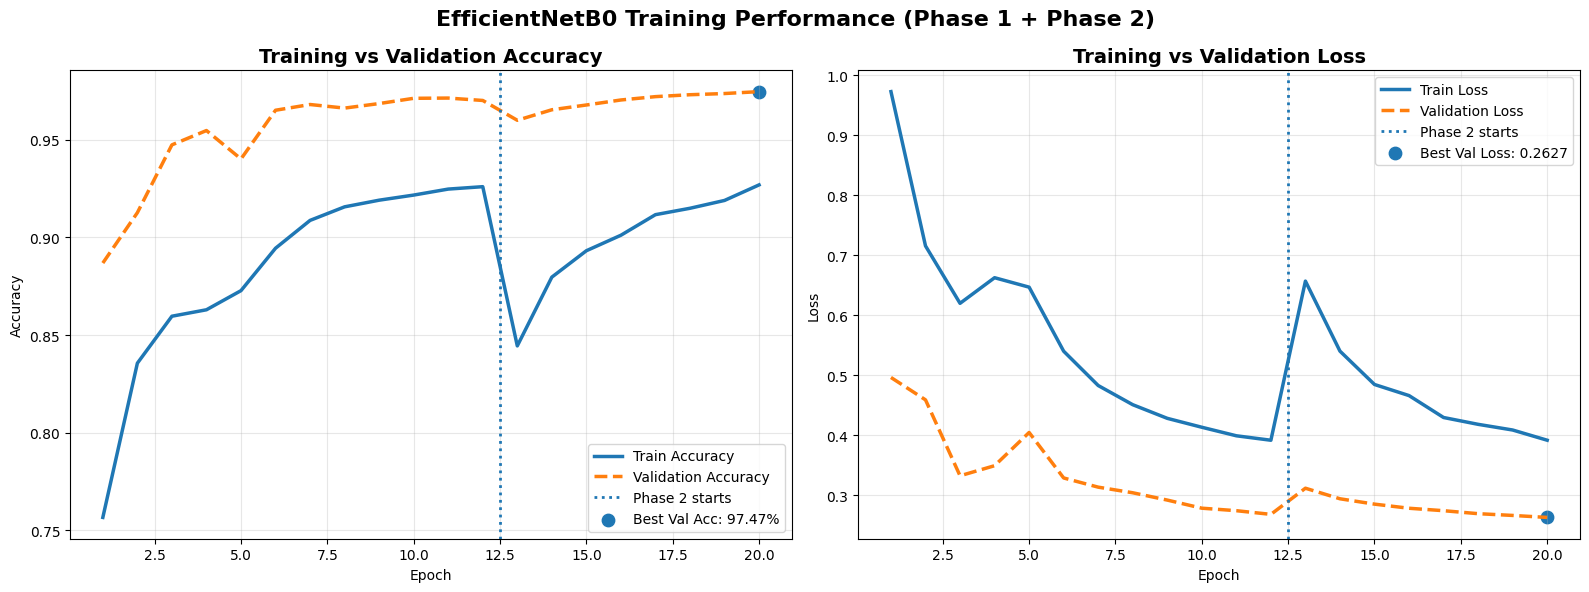

In [35]:
if isinstance(test_accuracy, tuple):
    test_accuracy = test_accuracy[0]

acc   = hist1.history['accuracy']     + hist2.history['accuracy']
vacc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
loss  = hist1.history['loss']         + hist2.history['loss']
vloss = hist1.history['val_loss']     + hist2.history['val_loss']

split = len(hist1.history['accuracy'])
epochs = list(range(1, len(acc) + 1))

best_val_acc_epoch  = int(np.argmax(vacc)) + 1
best_val_loss_epoch = int(np.argmin(vloss)) + 1

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc,  linewidth=2.5, label='Train Accuracy')
plt.plot(epochs, vacc, linewidth=2.5, linestyle='--', label='Validation Accuracy')
plt.axvline(split + 0.5, linestyle=':', linewidth=2, label='Phase 2 starts')
plt.scatter(best_val_acc_epoch, max(vacc), s=80, label=f'Best Val Acc: {max(vacc):.2%}')
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss,  linewidth=2.5, label='Train Loss')
plt.plot(epochs, vloss, linewidth=2.5, linestyle='--', label='Validation Loss')
plt.axvline(split + 0.5, linestyle=':', linewidth=2, label='Phase 2 starts')
plt.scatter(best_val_loss_epoch, min(vloss), s=80, label=f'Best Val Loss: {min(vloss):.4f}')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.suptitle('EfficientNetB0 Training Performance (Phase 1 + Phase 2)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_judges.png', dpi=200, bbox_inches='tight')
plt.show()

In [36]:
def fix_image(image_path):
    """
    Reads a real-world photo and applies:
      1. CLAHE
      2. White balance
      3. Bilateral filter
    Returns fixed BGR numpy array or None on error.
    """
    img = cv2.imread(image_path)

    if img is None:
        print(f' Could not read: {image_path}')
        print('Check the file path and upload.')
        return None

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    # White balance
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float32')
    avg_a = np.mean(lab[:, :, 1])
    avg_b = np.mean(lab[:, :, 2])

    lab[:, :, 1] -= (avg_a - 128) * (lab[:, :, 0] / 255.0) * 1.1
    lab[:, :, 2] -= (avg_b - 128) * (lab[:, :, 0] / 255.0) * 1.1

    img = cv2.cvtColor(
        np.clip(lab, 0, 255).astype('uint8'),
        cv2.COLOR_LAB2BGR
    )

    # Bilateral filter
    img = cv2.bilateralFilter(
        img,
        d=5,
        sigmaColor=50,
        sigmaSpace=50
    )

    return img


def show_fix(image_path):
    """Shows before vs after lighting fix side by side."""
    original = cv2.imread(image_path)

    if original is None:
        print(f' Could not read: {image_path}')
        return

    original = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    fixed = fix_image(image_path)
    if fixed is None:
        return

    fixed_rgb = cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(original_rgb)
    ax1.set_title('Original photo')
    ax1.axis('off')

    ax2.imshow(fixed_rgb)
    ax2.set_title('After lighting fix')
    ax2.axis('off')

    plt.suptitle('Lighting normalisation', fontsize=11)
    plt.tight_layout()
    plt.show()


print(' fix_image() and show_fix() ready')

 fix_image() and show_fix() ready


In [37]:
def show_severity(image_path):
    if not os.path.exists(image_path):
        print(f'File not found: {image_path}')
        return None, None

    img_fixed = fix_image(image_path)
    if img_fixed is None:
        return None, None

    img = cv2.resize(img_fixed, (IMG_SIZE, IMG_SIZE))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # Background mask
    bg_mask = ((v < 40) | (v > 240) | (s < 30))

    # Healthy green
    green_mask = (
        (h >= 35) & (h <= 85) &
        (s >= 40) & (v >= 40) &
        ~bg_mask
    )

    # Brown / yellow diseased region
    brown_mask = (
        (h >= 8) & (h <= 30) &
        (s >= 50) &
        (v >= 50) &
        ~bg_mask
    )

    # Dark brown / red lesions
    dark_brown_mask = (
        ((h <= 8) | (h >= 165)) &
        (s >= 50) &
        (v >= 40) & (v <= 180) &
        ~bg_mask
    )

    diseased_mask = brown_mask | dark_brown_mask

    n_green = int(np.sum(green_mask))
    n_diseased = int(np.sum(diseased_mask))
    total_leaf = max(n_green + n_diseased, 1)

    pct = round((n_diseased / total_leaf) * 100, 1)

    if n_diseased == 0:
        label = 'Healthy'
    elif pct < 5:
        label = 'Healthy'
    elif pct < 20:
        label = 'Mild'
    elif pct < 50:
        label = 'Moderate'
    else:
        label = 'Severe'

    color_map = {
        'Healthy':  (82, 183, 136),
        'Mild':     (233, 196, 106),
        'Moderate': (244, 162, 97),
        'Severe':   (231, 111, 81),
    }

    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    vis[diseased_mask] = color_map[label]

    debug = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    debug[green_mask] = (100, 200, 100)
    debug[diseased_mask] = (220, 80, 80)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Fixed image')
    axes[0].axis('off')

    axes[1].imshow(vis)
    axes[1].set_title(f'Severity: {pct}% — {label}')
    axes[1].axis('off')

    axes[2].imshow(debug)
    axes[2].set_title('Mask debug')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('severity_output.png', dpi=150)
    plt.show()

    print(f'Healthy pixels  : {n_green:,}')
    print(f'Diseased pixels : {n_diseased:,}')
    print(f'Severity        : {pct}%')
    print(f'Rating          : {label}')

    return pct, label


print('show_severity() ready')

show_severity() ready


In [38]:
def predict_image(image_path):
    img = fix_image(image_path)

    if img is None:
        print("Image not found")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pre = preprocess_input(img_rgb.astype("float32"))
    img_arr = np.expand_dims(img_pre, axis=0)

    preds = model.predict(img_arr, verbose=0)

    class_index = np.argmax(preds)
    confidence = np.max(preds)
    class_name = idx_to_class[class_index]

    if "___" in class_name:
        plant, disease = class_name.split("___")
    else:
        plant = class_name
        disease = "Unknown"

    print("\nPrediction Result")
    print("-----------------------")
    print(f"Plant      : {plant}")

    if disease.lower() == "healthy":
        print("Disease    : Healthy")
    else:
        print(f"Disease    : {disease.replace('_', ' ')}")

    print(f"Confidence : {confidence*100:.2f}%")

    return plant, disease, confidence


print('predict_image() ready')


predict_image() ready


Click "Choose Files" and select your leaf photo...


Saving test_potato_early_blight.jpg to test_potato_early_blight.jpg

 Uploaded: /content/test_potato_early_blight.jpg

── Step 1: Lighting fix 


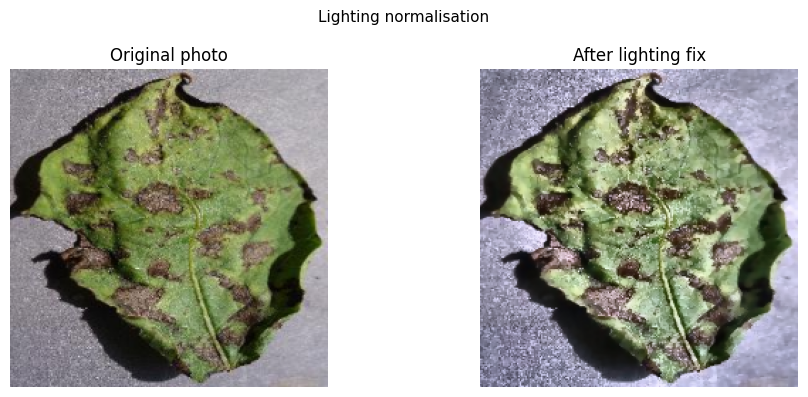

── Step 2: Severity score 


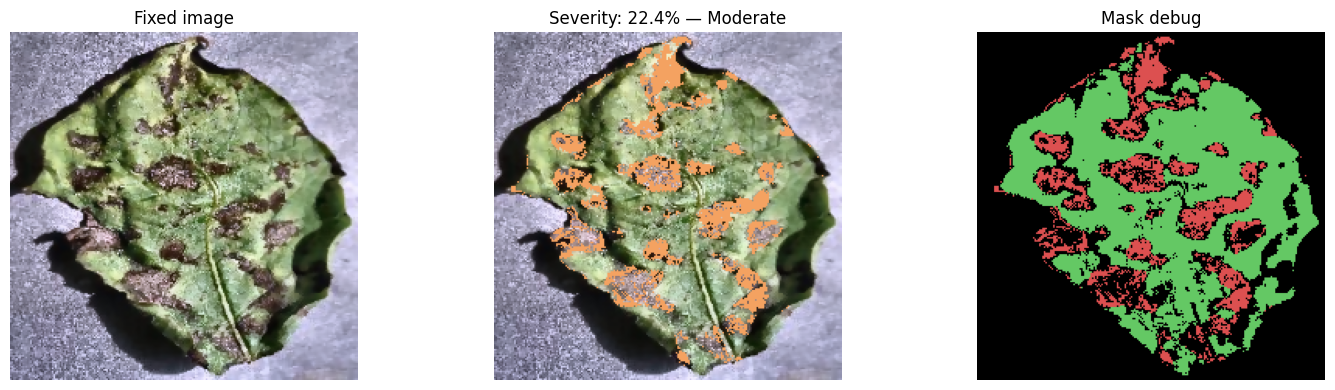

Healthy pixels  : 15,560
Diseased pixels : 4,482
Severity        : 22.4%
Rating          : Moderate
── Step 3: Prediction

Prediction Result
-----------------------
Plant      : Potato
Disease    : Early blight
Confidence : 100.00%


In [39]:
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Click "Choose Files" and select your leaf photo...')

    uploaded = colab_files.upload()
    filename = list(uploaded.keys())[0]
    test_image = f'/content/{filename}'

    if os.path.exists(test_image):
        print(f'\n Uploaded: {test_image}\n')

        print('── Step 1: Lighting fix ')
        show_fix(test_image)

        print('── Step 2: Severity score ')
        pct, sev_label = show_severity(test_image)

        print('── Step 3: Prediction')
        predict_image(test_image)
    else:
        print(' Upload failed. Please try again.')

else:
    print('Running outside Colab.')
    print('Set test_image = "/path/to/leaf.jpg" and run:')
    print('show_fix(test_image)')
    print('show_severity(test_image)')
    print('predict_image(test_image)')

Click "Choose Files" and select your leaf photo...


Saving test_blueberry_healthy.jpg to test_blueberry_healthy.jpg

 Uploaded: /content/test_blueberry_healthy.jpg

── Step 1: Lighting fix 


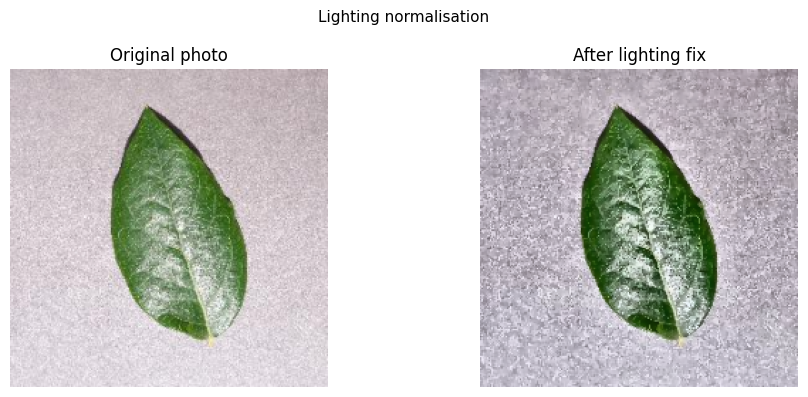

── Step 2: Severity score 


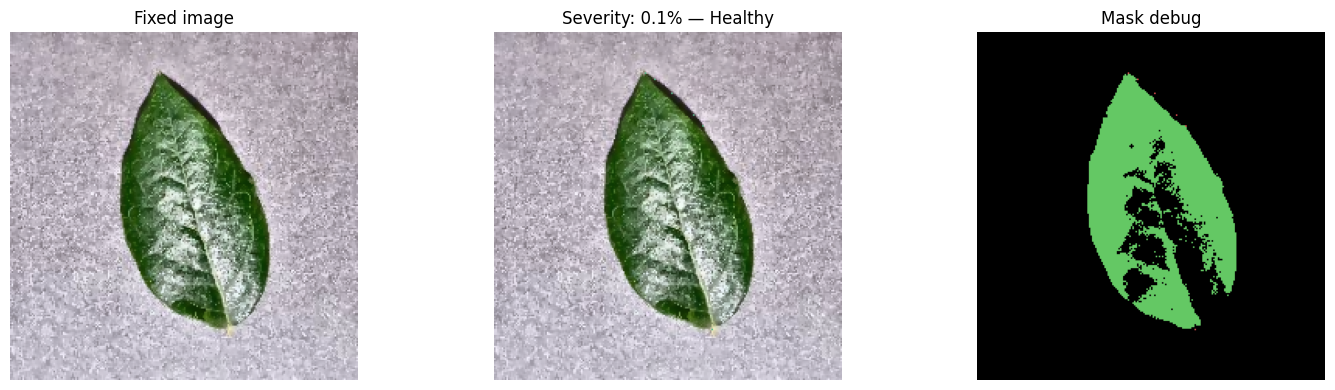

Healthy pixels  : 7,754
Diseased pixels : 6
Severity        : 0.1%
Rating          : Healthy
── Step 3: Prediction

Prediction Result
-----------------------
Plant      : Blueberry
Disease    : Healthy
Confidence : 100.00%


In [40]:
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Click "Choose Files" and select your leaf photo...')

    uploaded = colab_files.upload()
    filename = list(uploaded.keys())[0]
    test_image = f'/content/{filename}'

    if os.path.exists(test_image):
        print(f'\n Uploaded: {test_image}\n')

        print('── Step 1: Lighting fix ')
        show_fix(test_image)

        print('── Step 2: Severity score ')
        pct, sev_label = show_severity(test_image)

        print('── Step 3: Prediction')
        predict_image(test_image)
    else:
        print(' Upload failed. Please try again.')

else:
    print('Running outside Colab.')
    print('Set test_image = "/path/to/leaf.jpg" and run:')
    print('show_fix(test_image)')
    print('show_severity(test_image)')
    print('predict_image(test_image)')

In [41]:
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os
import shutil
import tensorflow as tf

print('Converting to TFLite...')

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]

    tflite_model = converter.convert()

    with open('plant_disease.tflite', 'wb') as f:
        f.write(tflite_model)

    print('TFLite model saved.')

except Exception as e:
    print(f'TFLite conversion failed: {e}')
    print('Full .keras model is still available.')

files_to_save = {
    'plant_disease_efficientnet.keras': 'Full model',
    'plant_disease.tflite': 'Mobile model',
    'class_indices.json': 'Class labels',
    'training_curves_judges.png': 'Training curves'
}

print('\n' + '='*50)
print('FILES READY')
print('='*50)

for fname, desc in files_to_save.items():
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / 1e6
        print(f'{desc:<20} {size_mb:>7.1f} MB   {fname}')
    else:
        print(f'{desc:<20} not found')

print('='*50 + '\n')

# Optional: save to Google Drive
drive_folder = "/content/drive/MyDrive/plant_disease_outputs"
os.makedirs(drive_folder, exist_ok=True)

for fname in files_to_save:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(drive_folder, fname))

print(f'Copied available files to: {drive_folder}')

# Download to local computer
if IN_COLAB:
    for fname in files_to_save:
        if os.path.exists(fname):
            colab_files.download(fname)

    print('All available files downloaded to your computer.')

else:
    print('Files saved in current working directory.')

Converting to TFLite...
Saved artifact at '/tmp/tmp3frybyl4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_239')
Output Type:
  TensorSpec(shape=(None, 40), dtype=tf.float32, name=None)
Captures:
  138420489495056: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  138420489501968: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  138420518688464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518690384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518690000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518691152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518689040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518690768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518693648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138420518693840: TensorSpec(shape=(),

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All available files downloaded to your computer.
